# EDA of high_diamond_ranked_10min.csv

## Import data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

file_path = '../data/raw/high_diamond_ranked_10min.csv'
df = pd.read_csv(file_path)

# print a summary of the data
print(df.shape)
df.head()

(9879, 40)


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


Check the amount of missing values in the data, describe some of the data and look at win rates of blue (sanity checks)

In [3]:
# df doesn't have any missing values
df.isnull().sum()

# check stats
df.describe()

# check win rate for blue (about 50% so data is fair)
df['blueWins'].value_counts(normalize=True)

blueWins
0    0.500962
1    0.499038
Name: proportion, dtype: float64

## Checking features that affect winrate

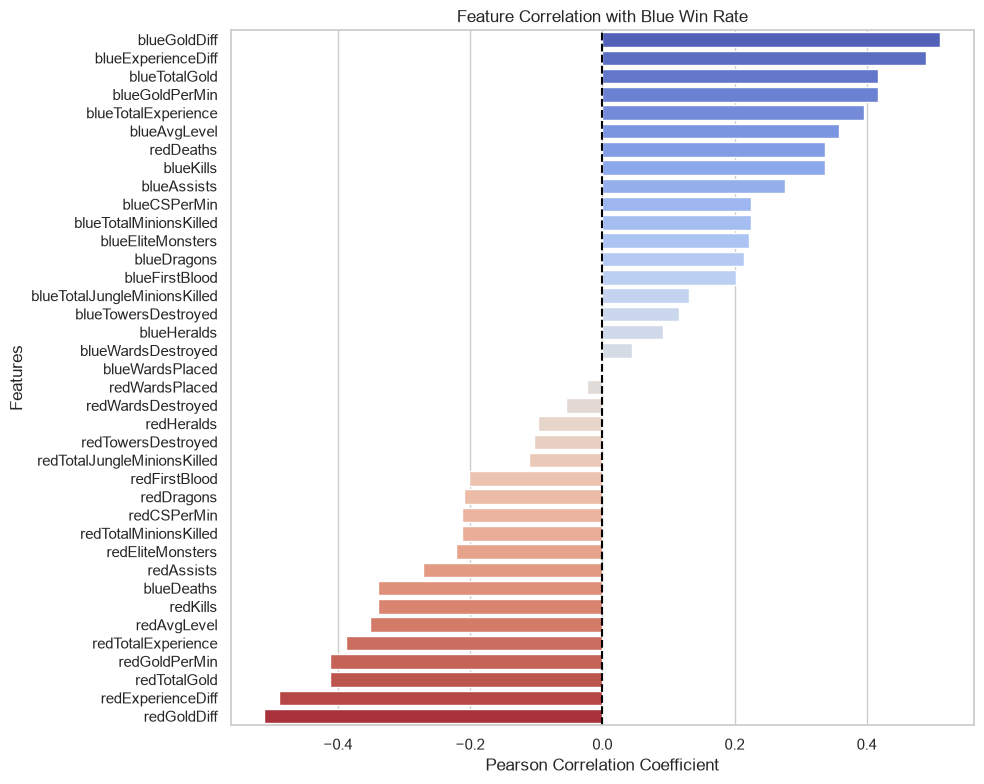

In [4]:
# calculate series to store correlations to wins
correlations = df.corr()['blueWins'].drop(['blueWins', 'gameId']).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,
    palette='coolwarm'
)

plt.axvline(0, color='black', linestyle='--')
plt.title('Feature Correlation with Blue Win Rate')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Something we can see from the figure is that the red teams stats correlation at 10 mins are essentially symmetrical to the blue teams stats correlation. The only stat for both sides that have negative correlation with the win rate is 'deaths' which is obvious.

This means we should engineer features that focus on the differential between the teams stats since a higher differential means a much higher win rate even if the team isn't doing that well in the stat compared to the average team.

## Multicollinearty

Something we need to consider for context is the snowball effect. In league an advantage in kills can mean a gold advantage which can naturally mean more map control and more objectives.

This means many features will have multicollinearity since they are all somewhat related. So need to consider ways to deal with multicollinearity very well. This includes not allowing very correlated features

<Axes: >

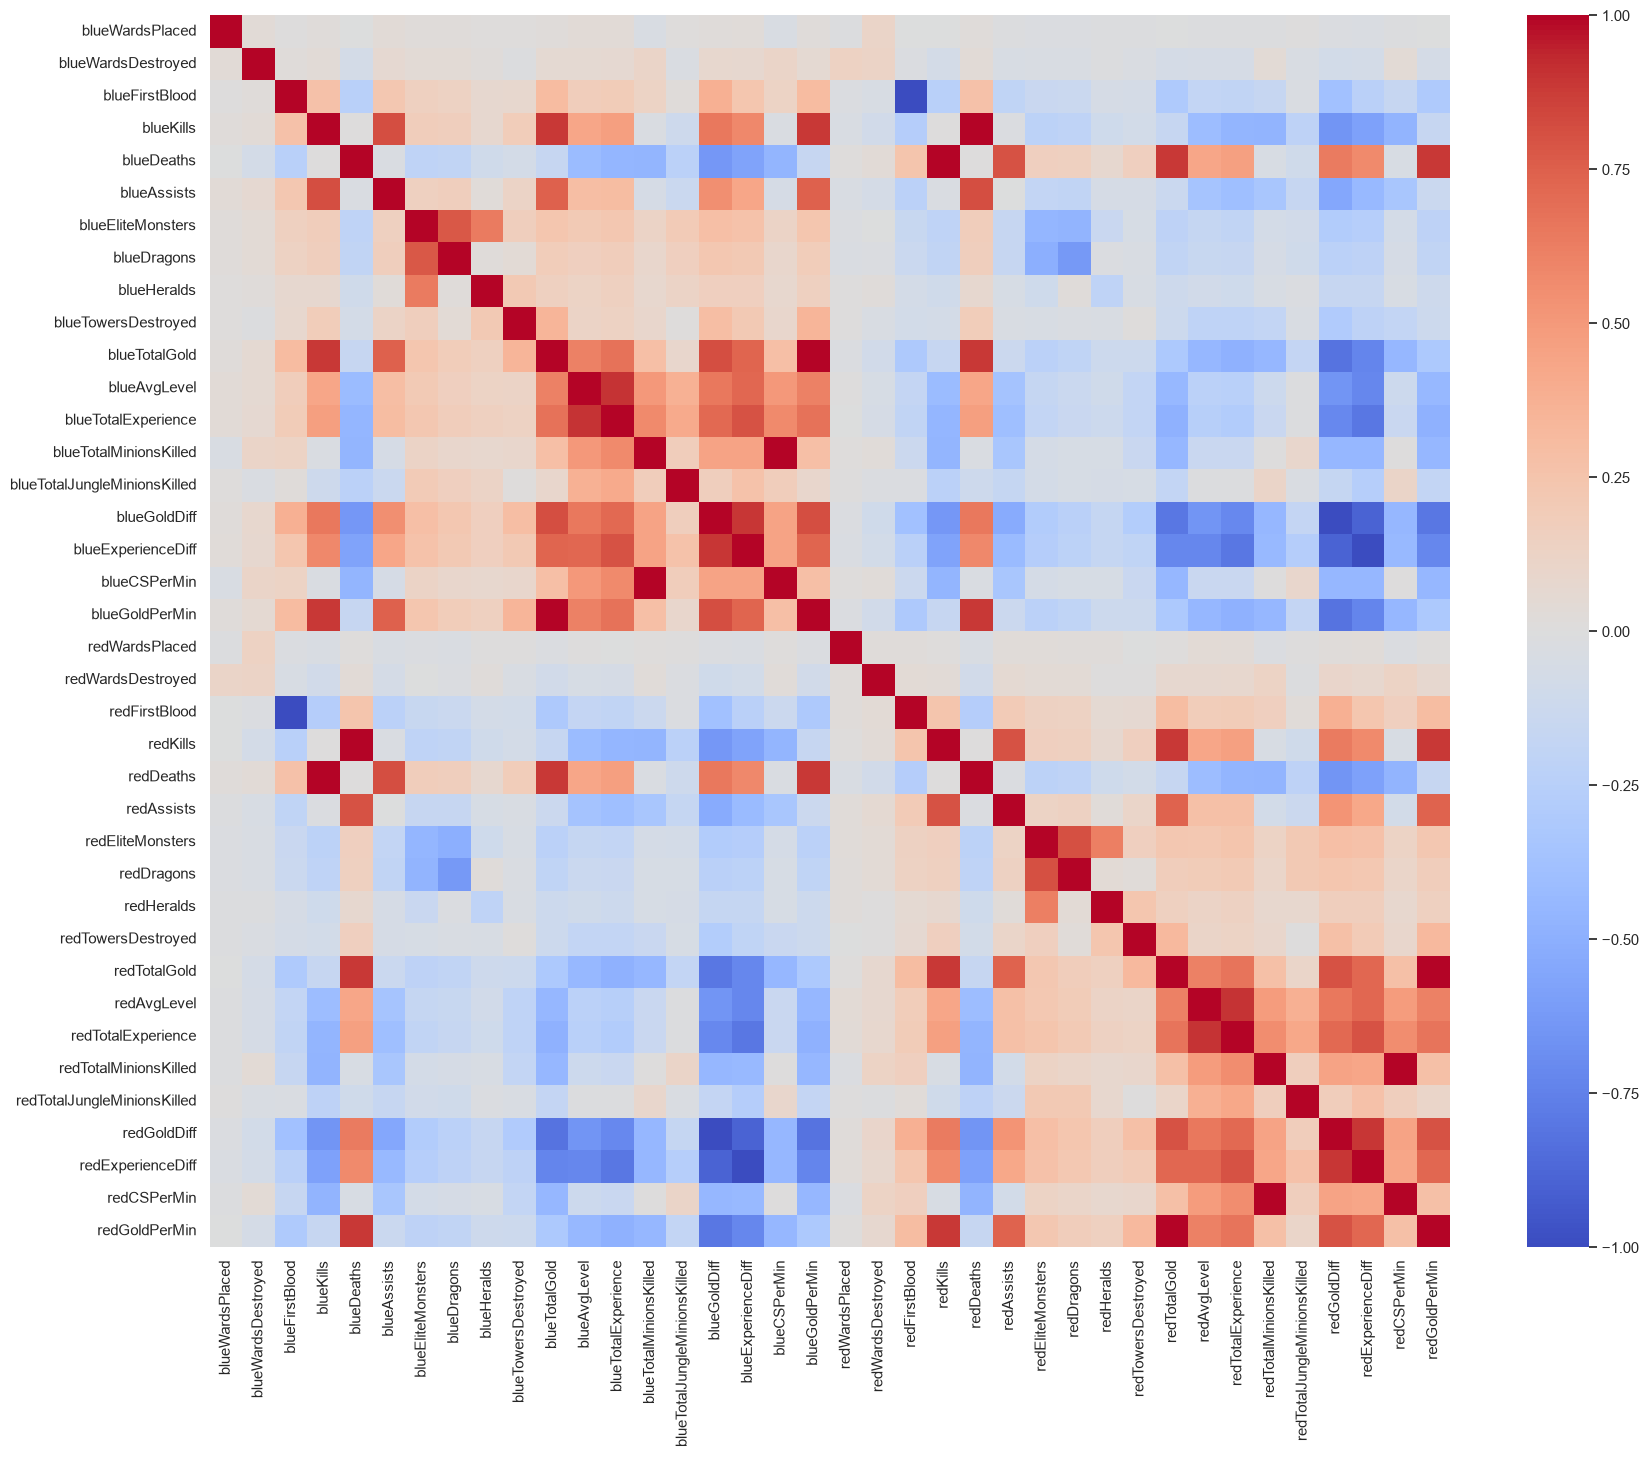

In [5]:
filtered_df = df.drop(columns=['blueWins', 'gameId'])
corr_df = filtered_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_df,
    cmap='coolwarm'
)

## Engineering features

I want to experiment on features and how much features to include. I plan to generate a big list of features and use statsmodel to determine AIC/BIC.

In [6]:
# add stat differential as features
# list of features ordered in estimated impact on blue side win rate
# renaming most cols to work with my naming convention
df['gold_diff'] = df['blueGoldDiff']
df['xp_diff'] = df['blueExperienceDiff']
df['kill_diff'] = df['blueKills'] - df['redKills']
df['cs_diff'] = df['blueCSPerMin'] - df['redCSPerMin']
df['objective_diff'] = df['blueEliteMonsters'] - df['redEliteMonsters']
df['first_blood'] = df['blueFirstBlood'] # 1 if blue fb, 0 o/w
df['jungle_diff'] = df['blueTotalJungleMinionsKilled'] - df['redTotalJungleMinionsKilled']
df['tower_diff'] = df['blueTowersDestroyed'] - df['redTowersDestroyed']
df['herald_diff'] = df['blueHeralds'] # 1 if blue has herald, 0 o/w
df['vision_diff'] = df['blueWardsPlaced'] + df['blueWardsDestroyed'] - df['redWardsPlaced'] - df['redWardsDestroyed']

Explanation of features (something to read if you are more knowledgable about league):
- gold_diff: very important, gold is essentially proportional to a teams power (we can't account for champions) because items mean power and more chance to win
- xp_diff: also very important, higher levels mean more stats for the winning team and a much higher chance of winning fights or being able to create pressure to end the game
- kill_diff: important since kills mean the opponent team have downtime, this allows the winning team to do things across the map to gain a lead
- first_blood: the first kill is usually one of the more important kills since it awards bonus gold
- objective_diff: this correlates a lot with dragons so we don't need to include dragon diff, objectives are important
- cs_diff: surprisingly CS doesn't relate that much with gold, only having a correlation of 0.45 which is safe, also CS is very important to deciding a game. The hypothesis is that CS can determine better lane state even if the opponent has gotten more kills etc
- jungle_diff: jungle diff is the difference in total camps cleared by both teams, since data is first 10 mins of the game this would usually be all of the junglers cs
- tower_diff: surprisingly low impact, towers and split pushing doesn't mean much back in 2020
- herald_diff: herald was seperated from objective gap since herald has significantly less impact and would affect the objective gap weighting if counted
- vision_diff: vision is a lot more useful than the stats would suggest but since the data is first 10 mins of the game vision doesn't get much impact to win rate


Apart from extremely obvious cases (blue deaths relate to red kills/cs per min being correlated to total cs) the multicollinearity of the data is not high.

## Feature Selection

Not all features are equal and some might not be needed for the predictive model. I want to calculate each model's AIC to find what features should be cut and then use these features for a ML model.

Note: I know using AIC is best with standard logistical regression model and not ML model but I am more comfortable with this and think this is sufficient enough anyways.

In [10]:
import statsmodels.api as sm

# create all candidate models
m1 = ['gold_diff', 'xp_diff']
m2 = m1 + ['kill_diff']
m3 = m2 + ['cs_diff']
m4 = m3 + ['objective_diff']
m5 = m4 + ['first_blood']
m6 = m5 + ['jungle_diff']
m7 = m6 + ['tower_diff']
m8 = m7 + ['herald_diff']
m9 = m8 + ['vision_diff']

candidate_models = {
    "m1 (Fundamental Factors)": m1,
    "m2 (+ Kills)": m2,
    "m3 (+ CS)": m3,
    "m4 (+ Objectives)": m4,
    "m5 (+ First Blood)": m5,
    "m6 (+ Jungle)": m6,
    "m7 (+ Towers)": m7,
    "m8 (+ Herald)": m8,
    "m9 (+ Vision)": m9
}

results = []
y = df['blueWins']

# test each one and record results
for model_name, features in candidate_models.items():
    X = df[features]
    X_const = sm.add_constant(X)

    try:
        model = sm.Logit(y, X_const).fit(disp=False)

        results.append({
            'Model': model_name,
            'Variables': len(features),
            'AIC': model.aic,
            'BIC': model.bic,
            'Log-likelihood': model.llf
        })
    except Exception as e:
        print(f'Skipped {model_name} due to error: {e}')

# sort them in a comparison table
results_df = pd.DataFrame(results)
results_df

,Model,Variables,AIC,BIC,Log-likelihood
0,m1 (Fundamental Factors),2,10585.543909,10607.138409,-5289.771955
1,m2 (+ Kills),3,10584.008203,10612.800869,-5288.004102
2,m3 (+ CS),4,10576.803060,10612.793892,-5283.401530
3,m4 (+ Objectives),5,10475.967291,10519.156291,-5231.983646
4,m5 (+ First Blood),6,10475.070591,10525.457757,-5230.535295
5,m6 (+ Jungle),7,10476.775210,10534.360542,-5230.387605
6,m7 (+ Towers),8,10467.758262,10532.541761,-5224.879131
7,m8 (+ Herald),9,10456.409685,10528.391350,-5218.204842
8,m9 (+ Vision),10,10458.310477,10537.490309,-5218.155238


Using AIC to determine the model we can say that m8 (the model which includes all features except vision) is the best model to use however using BIC which is more strict it tells us that m4 is the best model.

I won't be using a logistic regression model but thought using AIC would be good to access the impact of each feature and whether it should be included.

This means that for this project I will focus on a predictive ML model that engineers these features:
- gold diff
- exp diff
- kills diff
- cs diff
- objective diff
- first blood
- jungle diff
- towers diff
- herald diff

Vision will be excluded for having too little impact on the outcome in the first 10 mins